## Setup and Import the required libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pycountry_convert as pc
import subprocess
import os
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
import seaborn as sns
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
Pandas version: 2.3.3


## Data Preparation

 ## Preparing the air pollutants dataset

This code loads the Excel file, lists all available sheets (each with country/year data on population or pollutants),
and is designed to handle cases where some sheets have regions or indicators as columns (wide format).


In [2]:

# Explore the air pollutants dataset structure
file_path = 'data/aqdh-country-trends-major-air-pollutants-2003-2018.xlsx'
print(f"File exists: {Path(file_path).exists()}")

# First, let's see all sheet names
sheet_names = pd.read_excel(file_path, sheet_name=None).keys()
print(f"\nSheets in the Excel file:")
for i, sheet in enumerate(sheet_names, 1):
    print(f"  {i}. {sheet}")


File exists: True

Sheets in the Excel file:
  1. Title Page
  2. About and Methods
  3. Data Sources
  4. Data Dictionary
  5. Population (GPWv4.11)
  6. CO Population-Weighted (ppm)
  7. VOCs Population-Weighted (ppm)
  8. SO2 Population-Weighted (ppm)
  9. NOx Population-Weighted (ppm)
  10. O3 Population-Weighted (ppm)
  11. O3 Maximum (ppm)
  12. PM Pop.-Weighted (kg m^-3)
  13. CO Spatial-Avg (ppm)
  14. VOCs Spatial-Avg (ppm)
  15. SO2 Spatial-Avg (ppm)
  16. NOx Spatial-Avg (ppm)
  17. O3 Spatial-Avg (ppm)
  18. PM Spatial-Avg (kg m^-3)


This section processes and aggregates air pollution data from multiple excel sheets so now we are loading the required sheets beacuse this data set has unnessesary values such as spatial-Averages of the pollutants. Those values won't be
needed and we can only take population weighted values on the pollutants and the population.

In [3]:
sheets_needed = ['Population (GPWv4.11)','CO Population-Weighted (ppm)','VOCs Population-Weighted (ppm)','SO2 Population-Weighted (ppm)','NOx Population-Weighted (ppm)','O3 Population-Weighted (ppm)','PM Pop.-Weighted (kg m^-3)']

dfs = pd.read_excel(file_path, sheet_name=sheets_needed)

#Check the structure of the dataset
dfs['CO Population-Weighted (ppm)'].head()
dfs['CO Population-Weighted (ppm)'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   code     217 non-null    int64  
 1   iso      217 non-null    object 
 2   country  217 non-null    object 
 3   2003     217 non-null    float64
 4   2004     217 non-null    float64
 5   2005     217 non-null    float64
 6   2006     217 non-null    float64
 7   2007     217 non-null    float64
 8   2008     217 non-null    float64
 9   2009     217 non-null    float64
 10  2010     217 non-null    float64
 11  2011     217 non-null    float64
 12  2012     217 non-null    float64
 13  2013     217 non-null    float64
 14  2014     217 non-null    float64
 15  2015     217 non-null    float64
 16  2016     217 non-null    float64
 17  2017     217 non-null    float64
 18  2018     217 non-null    float64
dtypes: float64(16), int64(1), object(2)
memory usage: 32.3+ KB


All sheets are in wide data format,now converting them to the long format.

In [4]:
clean_dfs = {}

for sheet in sheets_needed:
    print(f"Processing: {sheet}")
    
    try:
        df = dfs[sheet].copy()
        
        # Check available columns
        print(f"  Columns: {df.columns.tolist()}")
        
        # remove only the numeric code
        if 'code' in df.columns:
            df = df.drop(columns=['code'])

        # Check which columns are id_vars
        id_vars = []
        for col in ['iso', 'country']:
            if col in df.columns:
                id_vars.append(col)
        
        if not id_vars:
            print(f"  ERROR: No id columns found! Available columns: {df.columns.tolist()}")
            continue
        
        df_long = df.melt(
            id_vars=id_vars,
            var_name='Year',
            value_name=sheet
        )

        df_long = df_long.rename(columns={
            'iso': 'ISO',
            'country': 'Country'
        })

        df_long['Year'] = df_long['Year'].astype(int)

        clean_dfs[sheet] = df_long
        print(f"  ✓ Successfully processed! Shape: {df_long.shape}")
        
    except Exception as e:
        print(f"  ERROR: {e}")

print(f"\nTotal sheets processed: {len(clean_dfs)}")

# Check one from the converted sheets
if clean_dfs:
    first_sheet = list(clean_dfs.keys())[0]
    print(f"\nSample from '{first_sheet}':")
    print(clean_dfs[first_sheet].head())



Processing: Population (GPWv4.11)
  Columns: ['code', 'iso', 'country', 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
  ✓ Successfully processed! Shape: (3456, 4)
Processing: CO Population-Weighted (ppm)
  Columns: ['code', 'iso', 'country', 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
  ✓ Successfully processed! Shape: (3472, 4)
Processing: VOCs Population-Weighted (ppm)
  Columns: ['code', 'iso', 'country', 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
  ✓ Successfully processed! Shape: (3472, 4)
Processing: SO2 Population-Weighted (ppm)
  Columns: ['code', 'iso', 'country', 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
  ✓ Successfully processed! Shape: (3472, 4)
Processing: NOx Population-Weighted (ppm)
  Columns: ['code', 'iso', 'country', 2003, 2004, 2005, 2006, 2007, 2008, 2009, 20

Merging all long formatted data into a one sheet

In [5]:
from functools import reduce

# Get all dataframes
dfs_to_merge = list(clean_dfs.values())

# Merge all dataframes on ISO, Country, Year
merged_pollution_df = reduce(
    lambda left, right: pd.merge(left, right, on=['ISO', 'Country', 'Year'], how='inner'),
    dfs_to_merge
)

print("Merged dataset shape:", merged_pollution_df.shape)
merged_pollution_df.head()

Merged dataset shape: (3456, 10)


,ISO,Country,Year,Population (GPWv4.11),CO Population-Weighted (ppm),VOCs Population-Weighted (ppm),SO2 Population-Weighted (ppm),NOx Population-Weighted (ppm),O3 Population-Weighted (ppm),PM Pop.-Weighted (kg m^-3)
0,AFG,Afghanistan,2003,22505753.96,0.183874,0.014393,0.001214,0.002699,0.058293,2.146440e-08
1,ALB,Albania,2003,3007855.17,0.196819,0.009877,0.016917,0.011609,0.059549,1.752210e-08
2,DZA,Algeria,2003,31696677.04,0.170953,0.021907,0.006183,0.016220,0.061580,2.549140e-08
3,AND,Andorra,2003,66408.62,0.199238,0.012210,0.007149,0.013281,0.054613,1.578730e-08
4,AGO,Angola,2003,16689290.34,0.305001,0.060220,0.001648,0.007788,0.045467,3.123360e-08


Checking Missing values, Duplicates and Exporting the cleaned dataset

In [6]:
#check duplicates in ISO, Country, Year
merged_pollution_df.duplicated(subset=['ISO','Country','Year']).sum()

#check missing values in the merged dataset
print(merged_pollution_df.isnull().sum())

merged_pollution_df.to_csv(
    "data/air_pollutant_dataset_CLEANED.csv",
    index=False
)

ISO                               0
Country                           0
Year                              0
Population (GPWv4.11)             0
CO Population-Weighted (ppm)      0
VOCs Population-Weighted (ppm)    0
SO2 Population-Weighted (ppm)     0
NOx Population-Weighted (ppm)     0
O3 Population-Weighted (ppm)      0
PM Pop.-Weighted (kg m^-3)        0
dtype: int64


## Preparing the Hospital Bed Values Dataset

In [7]:
# Load the hospital beds data

# The hospital beds dataset also comes from the World Bank and contains metadata/header rows at the top.
# We set skiprows=4 to start reading from the actual data table.

csv_path = 'data/Hospital_beds.csv'


df = pd.read_csv(csv_path, skiprows=4)

print("Column names:", df.columns.tolist()[:10])  # Show first 10 columns
print("\nDataframe shape:", df.shape)
print("\nDataframe info:")
df.info()
print("\nFirst few rows:")
print(df[['Country Name', 'Country Code'] + [col for col in df.columns if str(col).isdigit()][:5]].head())

# Now properly transform the data
# Select country, code, and year columns
year_cols = [col for col in df.columns if str(col).isdigit()]
print(f"\nYear columns found: {year_cols[:10]}...")  # Show first 10

beds_df = df[['Country Name', 'Country Code'] + year_cols].copy()

# Convert from wide to long format so that each row is a country-year with a "Hospital beds (per 1,000 people)" value.
beds_long = beds_df.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='HospitalBeds'
)

# Rename columns
beds_long = beds_long.rename(columns={
    'Country Name': 'Country',
    'Country Code': 'ISO'
})

# Convert year to integer and beds to numeric (handle empty strings)
beds_long['Year'] = beds_long['Year'].astype(int)
beds_long['HospitalBeds'] = pd.to_numeric(beds_long['HospitalBeds'], errors='coerce')

print("\n\nTransformed dataset:")
print(beds_long.head(10))
print(beds_long.info())

#check missing values in the transformed dataset
print("\nMissing values:", beds_long['HospitalBeds'].isna().sum())

#check for duplicates in ISO, Country, Year
beds_long.duplicated(subset=['Country','ISO','Year']).sum()


beds_long.to_csv(
    "data/hospital_beds_dataset_CLEANED.csv",
    index=False
)


Column names: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965']

Dataframe shape: (266, 71)

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            162 non-null    float64
 5   1961            2 non-null      float64
 6   1962            2 non-null      float64
 7   1963            2 non-null      float64
 8   1964            2 non-null      float64
 9   1965            8 non-null      float64
 10  1966            5 non-null      float64
 11  1967            5 non-null      float64
 12  1968            5 non-null      float64
 13  1969            5 non-null      float64

## Preparing the Air Pollution Death Rate Dataset

In [8]:


csv_path = 'data/air_pollution_death_rate.csv'
print("checking existence:", Path(csv_path).exists())

# load and show a few rows

df = pd.read_csv(csv_path)

# check the structure of the dataset
df.info()
df.head()
df.describe()

#filtering the sex category for both sexes and the cause category for all causes combined
df = df[
    (df["Dim1ValueCode"] == "SEX_BTSX") &          # Both sexes only
    (df["Dim2ValueCode"] == "GHECAUSE_GHE000000")  # All causes combined
].reset_index(drop=True)

# Keep only 5 columns
df = df[['Location','SpatialDimValueCode', 'Period', 'FactValueNumeric']]


#Check the dataset again after filtering
df.head()

#rename columns for clarity
df = df.rename(columns={'SpatialDimValueCode': 'ISO','Location': 'Country', 'Period': 'Year', 'FactValueNumeric': 'DeathRate'})

#checking missing values
print(df.isnull().sum())

#check for duplicates in country and year
df.duplicated(subset=['Country','Year']).sum()

df[df.duplicated(subset=['Country','Year'], keep=False)]


#Export the cleaned dataset to a new CSV file
df.to_csv(
    "data/death_rates_dataset_CLEANED.csv",
    index=False
)


checking existence: True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32940 entries, 0 to 32939
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IndicatorCode               32940 non-null  object 
 1   Indicator                   32940 non-null  object 
 2   ValueType                   32940 non-null  object 
 3   ParentLocationCode          32940 non-null  object 
 4   ParentLocation              32940 non-null  object 
 5   Location type               32940 non-null  object 
 6   SpatialDimValueCode         32940 non-null  object 
 7   Location                    32940 non-null  object 
 8   Period type                 32940 non-null  object 
 9   Period                      32940 non-null  int64  
 10  IsLatestYear                32940 non-null  bool   
 11  Dim1 type                   32940 non-null  object 
 12  Dim1                        32940 non-null  object 
 13  Dim1Va

## Comparing and Merging the Datasets



In [9]:
pollution = pd.read_csv("data/air_pollutant_dataset_CLEANED.csv")
death = pd.read_csv("data/death_rates_dataset_CLEANED.csv")
beds = pd.read_csv("data/hospital_beds_dataset_CLEANED.csv")

#check the structure of the datasets
pollution.head()
beds.head()
death.head()

#check the ranges
print("Pollution:", pollution['Year'].min(), "-", pollution['Year'].max())
print("Hospital beds:", beds['Year'].min(), "-", beds['Year'].max())
print("Death rate:", death['Year'].min(), "-", death['Year'].max())

Pollution: 2003 - 2018
Hospital beds: 1960 - 2025
Death rate: 2010 - 2019


**Merging Strategy**

- Find the common year range across all datasets to ensure consistency.  
- Use an inner join to merge death rate and pollution data because both are core variables that must exist together for every row.  
- Use a left join to add hospital beds data, since it is supplementary and missing values can be handled later.

In [10]:
start_year = max(
    pollution['Year'].min(),
    beds['Year'].min(),
    death['Year'].min()
)

end_year = min(
    pollution['Year'].max(),
    beds['Year'].max(),
    death['Year'].max()
)

#common year range for all datasets: 2010-2018
print("Common year range:", start_year, "-", end_year)

#Filter datasets to the common year range
pollution = pollution[
    (pollution['Year'] >= start_year) &
    (pollution['Year'] <= end_year)
]

beds = beds[
    (beds['Year'] >= start_year) &
    (beds['Year'] <= end_year)
]

death = death[
    (death['Year'] >= start_year) &
    (death['Year'] <= end_year)
]

# merge – you may also supply suffixes explicitly if you like
base   = death.copy()
merged = base.merge(pollution, on=["ISO","Year"], how="inner",
                     suffixes=("","_p"))
merged = merged.merge(beds,      on=["ISO","Year"], how="left",
                      suffixes=("","_b"))

# drop any remaining Country* columns and duplicates
merged = merged.loc[:, ~merged.columns.str.startswith("Country")]
merged = merged.drop_duplicates(subset=["ISO","Year"])

# persist the result
final_df = merged.copy()


final_df.head()
final_df.isnull().sum()



Common year range: 2010 - 2018


ISO                                 0
Year                                0
DeathRate                           0
Population (GPWv4.11)               0
CO Population-Weighted (ppm)        0
VOCs Population-Weighted (ppm)      0
SO2 Population-Weighted (ppm)       0
NOx Population-Weighted (ppm)       0
O3 Population-Weighted (ppm)        0
PM Pop.-Weighted (kg m^-3)          0
HospitalBeds                      407
dtype: int64

## Handling the missing hospital bed values

In [11]:
#Adding country wise mean of hospital beds to fill the missing values in the HospitalBeds column    
final_df['HospitalBeds'] = final_df.groupby('ISO')['HospitalBeds'].transform(lambda x: x.fillna(x.mean()))

#check the missing values in the final dataset again after filling the missing values in the HospitalBeds column and still
# 162 bed values are missing we are keeping that still for now
final_df.isnull().sum()


os.makedirs("final_datasets", exist_ok=True)



**After filling with country means, there are 162 unique countries still missing 'Hospital beds (per 1,000 people)' data. we are keeping those values still for now**

 **The code below verifies that the remaining missing data for 'Hospital beds (per 1,000 people)'is due to a specific number of countries (X), for every year present** 


In [12]:
remaining_missing = final_df[final_df['HospitalBeds'].isna()]

num_countries      = remaining_missing['ISO'].nunique()
years              = remaining_missing['Year'].nunique()
num_missing_records = remaining_missing.shape[0]

print(f"{num_countries} countries × {years} years = {num_countries * years}")
assert num_countries * years == num_missing_records, \
    "Mismatch: some countries are missing only partial years, not all."

print(
    f"\n{num_missing_records} records remain missing across "
    f"{num_countries} countries after country-mean imputation. "
    f"These countries had no recorded HospitalBeds values in any year, "
    f"so no country mean could be calculated — regional median imputation will be applied next."
)

18 countries × 9 years = 162

162 records remain missing across 18 countries after country-mean imputation. These countries had no recorded HospitalBeds values in any year, so no country mean could be calculated — regional median imputation will be applied next.


## Basic Data inspection of the final dataset

In [13]:
final_df.shape
final_df.head()

,ISO,Year,DeathRate,Population (GPWv4.11),CO Population-Weighted (ppm),VOCs Population-Weighted (ppm),SO2 Population-Weighted (ppm),NOx Population-Weighted (ppm),O3 Population-Weighted (ppm),PM Pop.-Weighted (kg m^-3),HospitalBeds
0,SLE,2018,99.59,6254681.32,0.268831,0.063560,0.001600,0.004364,0.051219,4.936920e-08,NaN
1,GIN,2018,100.70,13468721.71,0.265497,0.075247,0.002076,0.004869,0.050023,4.568590e-08,0.300
2,CAF,2018,103.60,5217309.81,0.343126,0.298347,0.001055,0.004225,0.036538,3.312480e-08,1.000
3,LSO,2018,104.40,2168672.44,0.189268,0.030683,0.023860,0.017731,0.051924,1.172620e-08,NaN
4,TCD,2018,104.40,15415574.37,0.184663,0.107295,0.000606,0.003380,0.047606,4.279680e-08,0.455


## Statistical Summary of the Final Dataset

In [14]:
# statistical summary of the dataset mean, median, std, min, max, etc.
final_df.describe().drop(columns=["Year"], errors="ignore")

,DeathRate,Population (GPWv4.11),CO Population-Weighted (ppm),VOCs Population-Weighted (ppm),SO2 Population-Weighted (ppm),NOx Population-Weighted (ppm),O3 Population-Weighted (ppm),PM Pop.-Weighted (kg m^-3),HospitalBeds
count,1647.000000,1.647000e+03,1647.000000,1647.000000,1647.000000,1647.000000,1647.000000,1.647000e+03,1485.000000
mean,56.104542,3.875060e+07,0.206872,0.033816,0.013423,0.011761,0.051687,2.691081e-08,2.923084
std,33.114935,1.412536e+08,0.134220,0.040529,0.027413,0.012659,0.007357,2.072052e-08,2.415274
min,7.570000,2.475500e+03,0.048889,0.000480,0.000146,0.000011,0.025880,4.475260e-09,0.180000
25%,27.985000,2.531585e+06,0.135392,0.008475,0.001683,0.003556,0.046810,1.280595e-08,1.120000
50%,53.170000,8.705115e+06,0.169657,0.021329,0.005119,0.007758,0.051627,1.803780e-08,2.250000
75%,75.240000,2.799347e+07,0.236428,0.045546,0.012474,0.015648,0.056195,3.706745e-08,3.950000
max,187.200000,1.369607e+09,0.912018,0.382680,0.271160,0.079860,0.081121,1.103720e-07,14.300000


**Plotting death rate per year for each country**

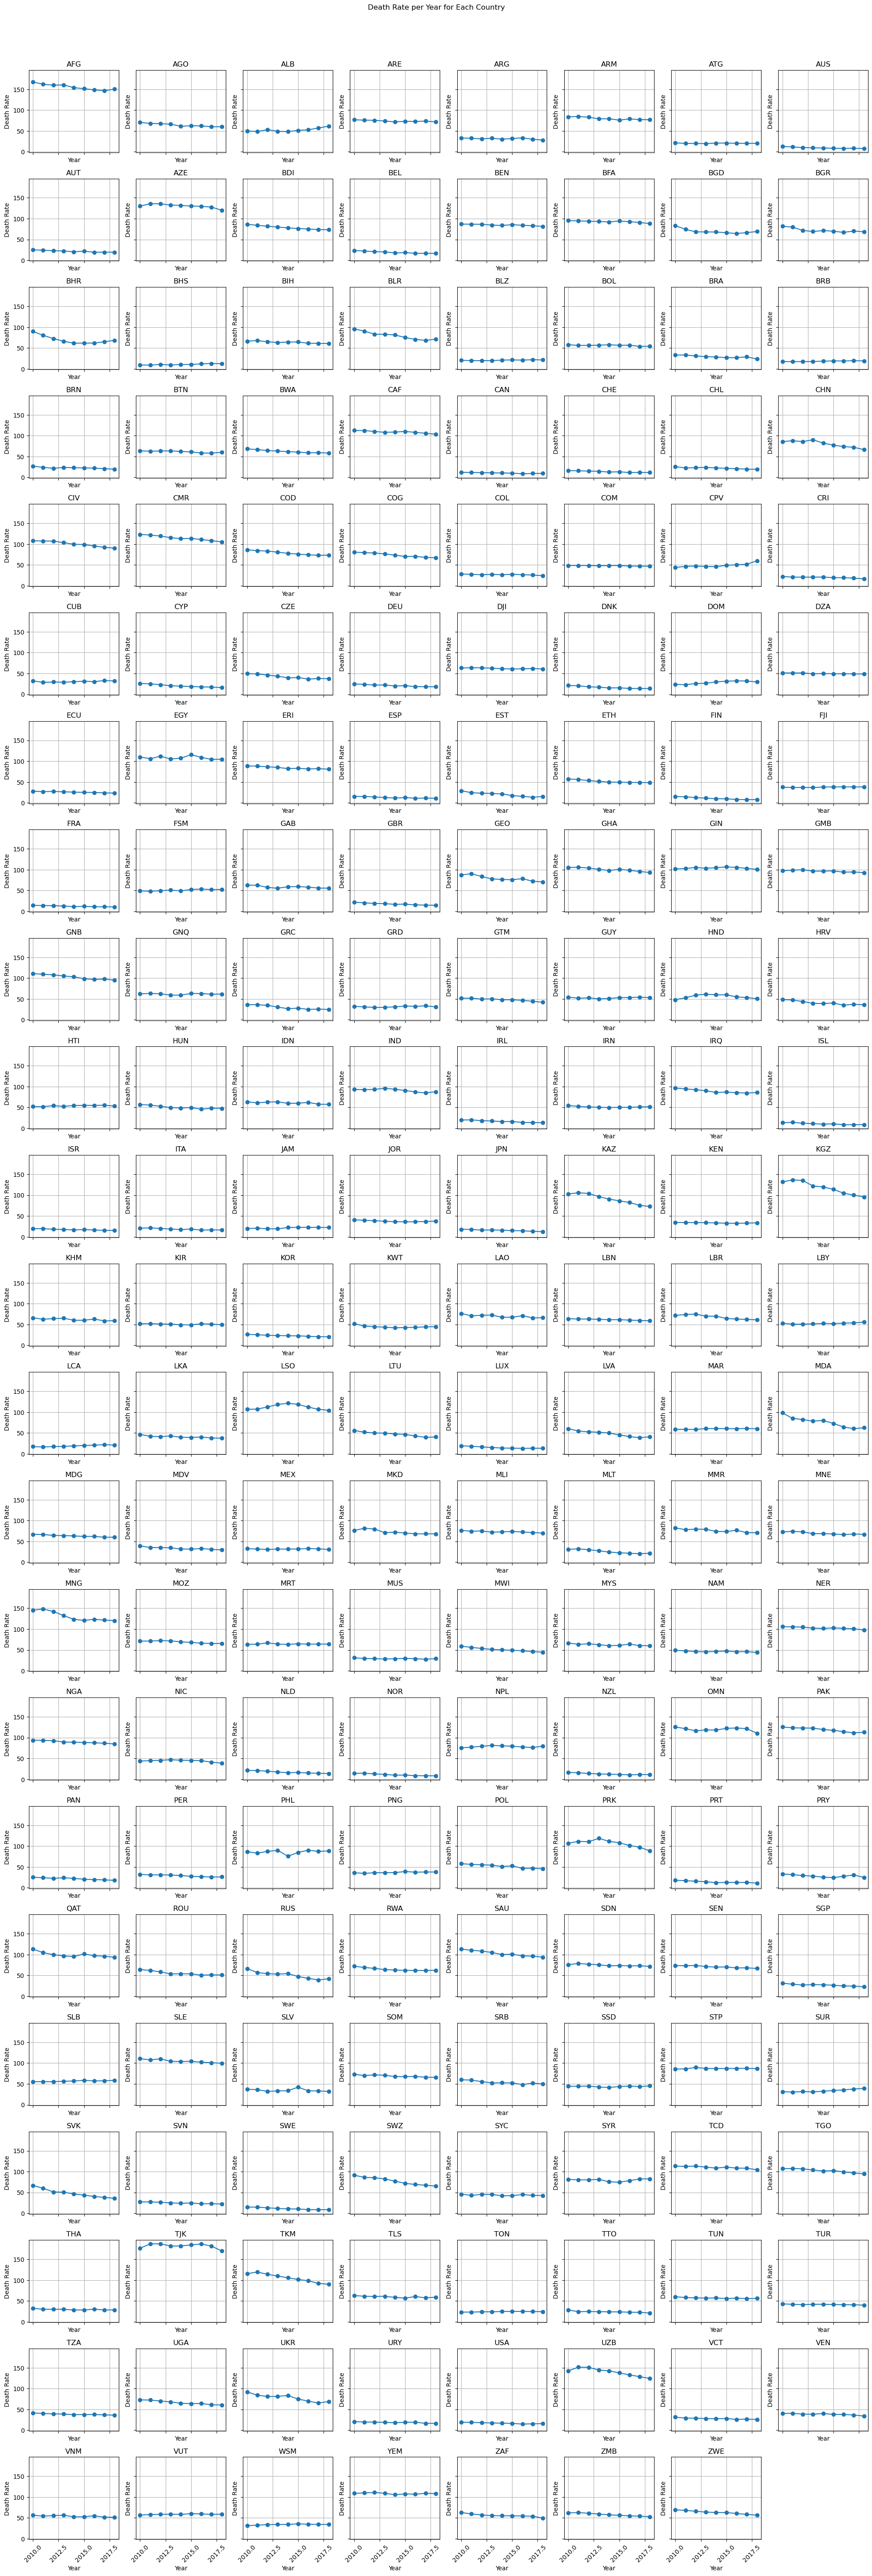

In [15]:
# Plot death rate per year for each country
unique_countries = final_df['ISO'].unique()
 
fig, axes = plt.subplots(
    nrows=len(unique_countries) // 8 + 1,
    ncols=8,
    figsize=(20, 2.5 * (len(unique_countries) // 8 + 1)),
    sharex=True,
    sharey=True
)
axes = axes.flatten()
 
for i, iso in enumerate(sorted(unique_countries)):
    ax = axes[i]
    country_data = final_df[final_df['ISO'] == iso]
    ax.plot(country_data['Year'], country_data['DeathRate'], marker='o')
    ax.set_title(iso)
    ax.set_xlabel('Year')
    ax.set_ylabel('Death Rate')
    ax.grid(True)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
 
# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
 
fig.tight_layout()
plt.suptitle('Death Rate per Year for Each Country', y=1.02)
plt.show()
 

## Histrograms

Showing the frequency of each features and target variable

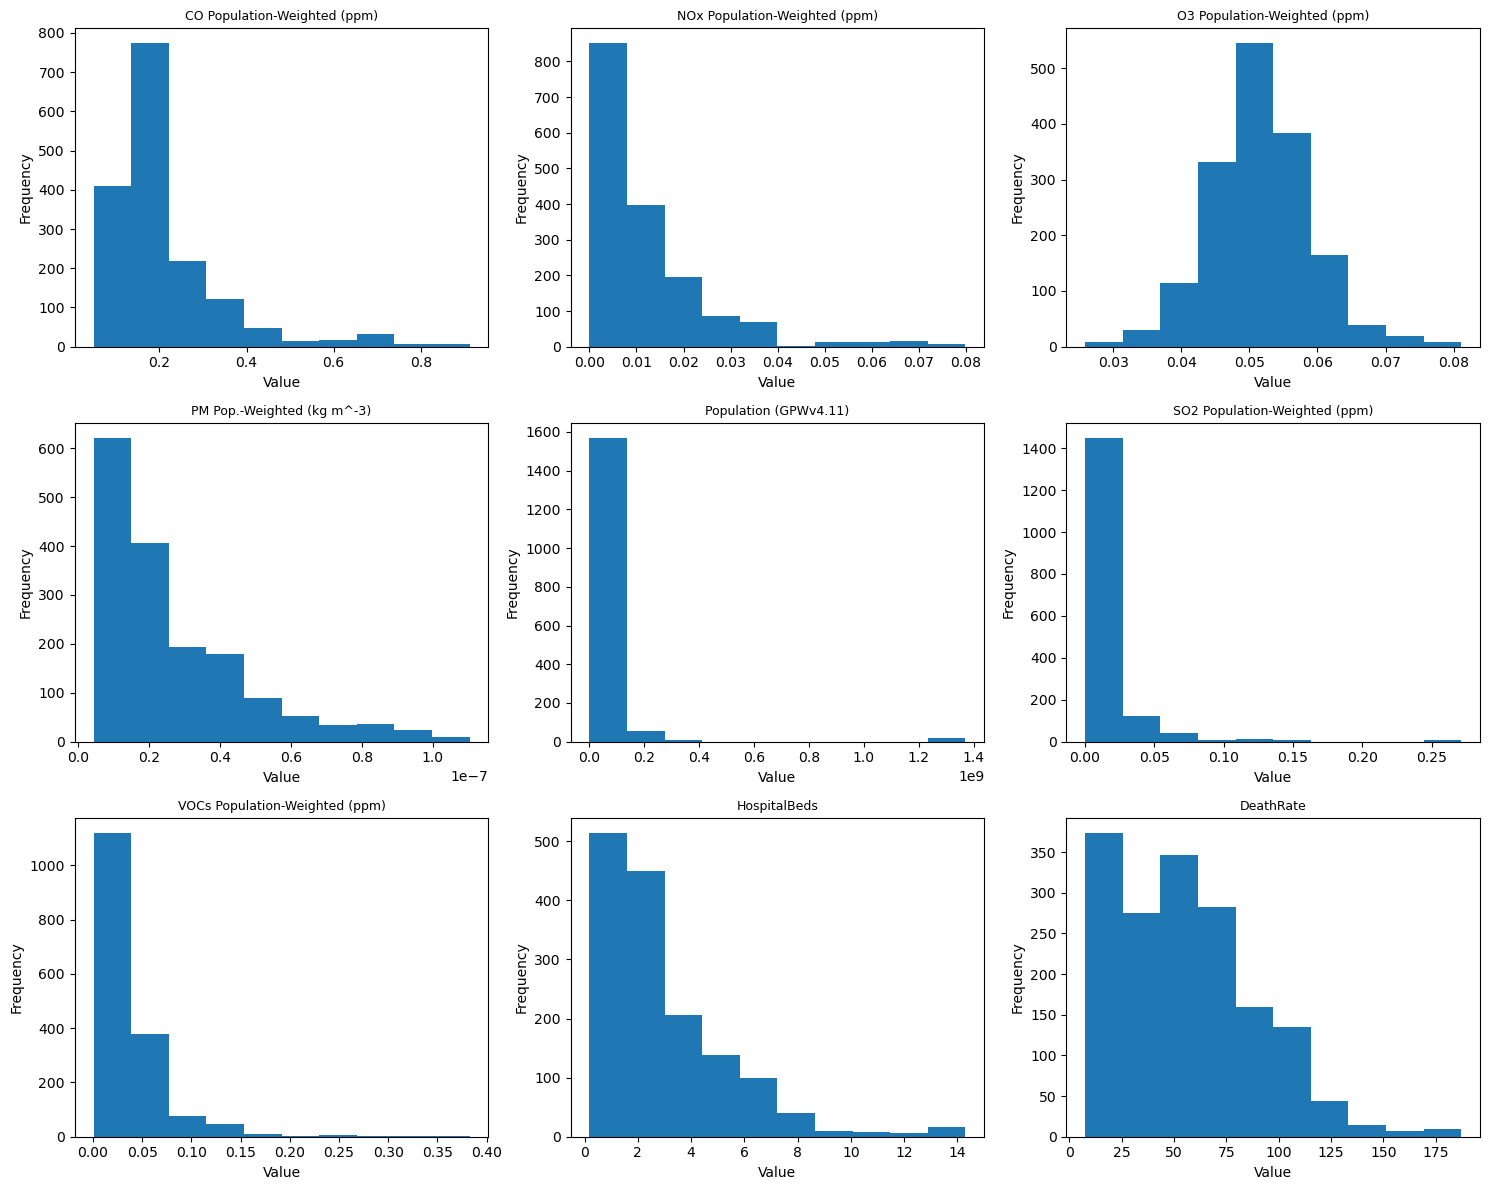

In [16]:
# Distribution of all features and target variable
all_features = [
    'CO Population-Weighted (ppm)',
    'NOx Population-Weighted (ppm)',
    'O3 Population-Weighted (ppm)',
    'PM Pop.-Weighted (kg m^-3)',
    'Population (GPWv4.11)',
    'SO2 Population-Weighted (ppm)',
    'VOCs Population-Weighted (ppm)',
    'HospitalBeds',
    'DeathRate'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(all_features):
    axes[i].hist(final_df[col].dropna(), bins=10)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

## Analyze Correlations: Heatmaps to Find Highly Correlated Features

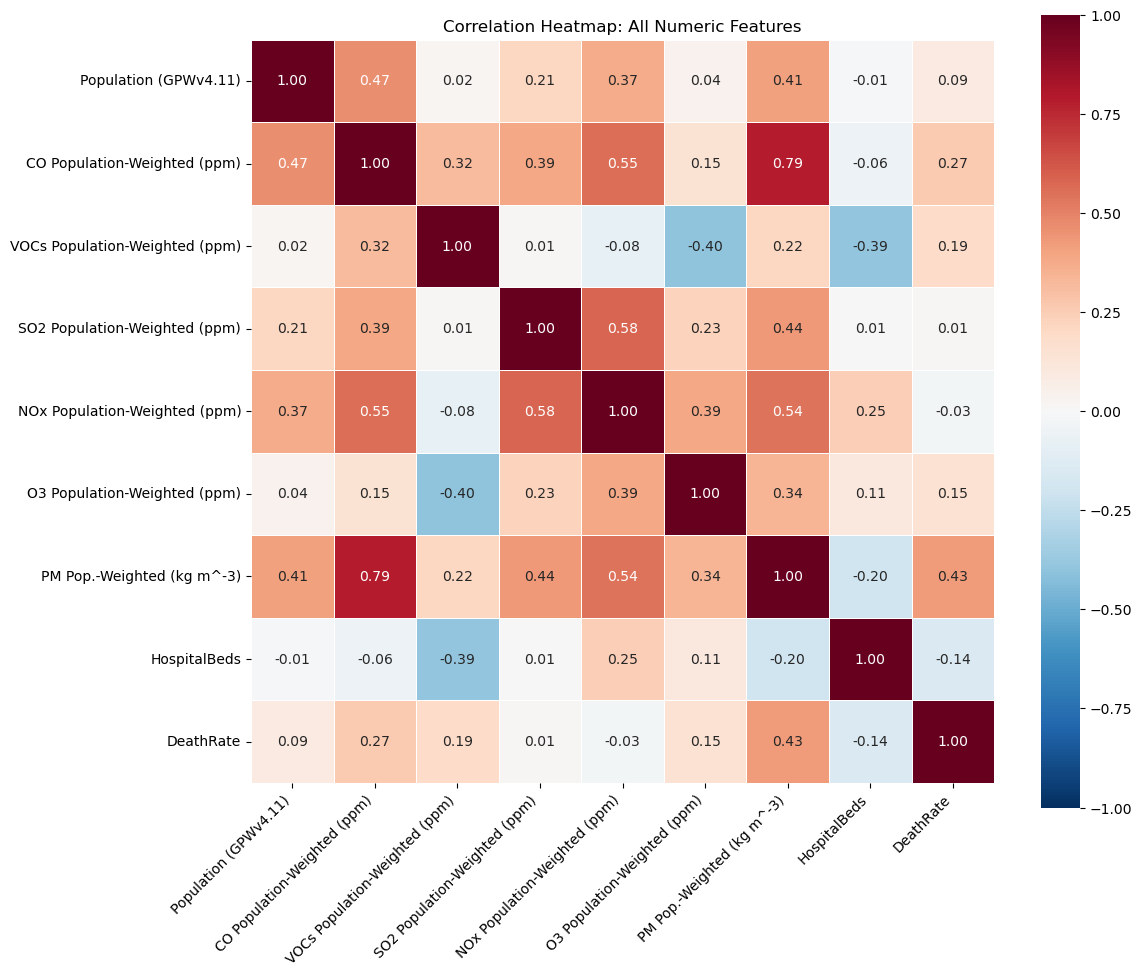

In [17]:
# Remove non-feature columns
# Put DeathRate last so it appears at the bottom row — easier to read
df_corr = final_df.drop(columns=['ISO', 'Year'])
cols = [c for c in df_corr.columns if c != 'DeathRate'] + ['DeathRate']
df_corr = df_corr[cols]
 
# Calculate correlation
corr = df_corr.corr()
 
# Plot heatmap — styled to match friend's map
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',      # same colormap as friend
    vmin=-1, vmax=1,    # full standard -1 to 1 scale
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Heatmap: All Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
 

## Focused correlation bar chart

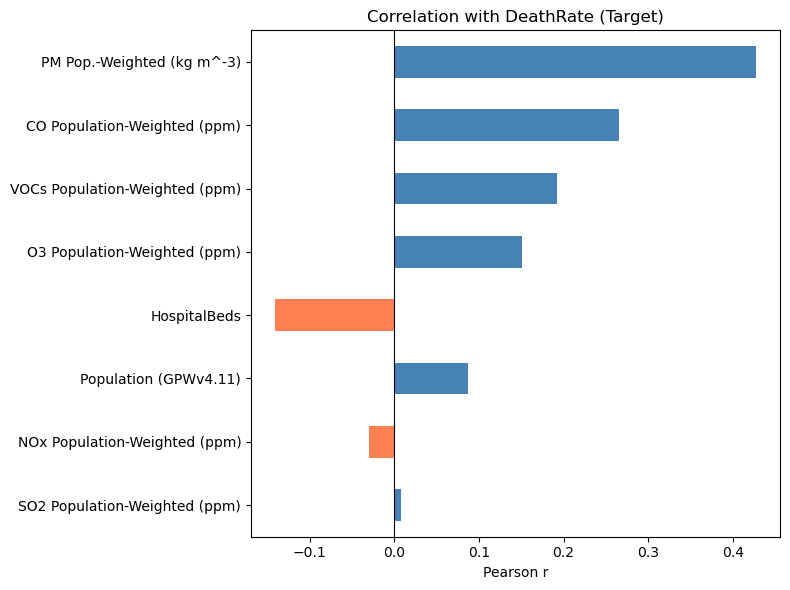

In [18]:
# Focused correlation bar chart — each feature vs DeathRate
df_corr = final_df.drop(columns=['ISO', 'Year'])

corr_with_target = df_corr.corr()['DeathRate'].drop('DeathRate')
corr_with_target = corr_with_target.reindex(
    corr_with_target.abs().sort_values().index  # sort by absolute value
)

colors = ['steelblue' if c >= 0 else 'coral' for c in corr_with_target]

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with DeathRate (Target)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

## Scatter plots: Features vs Death_rate

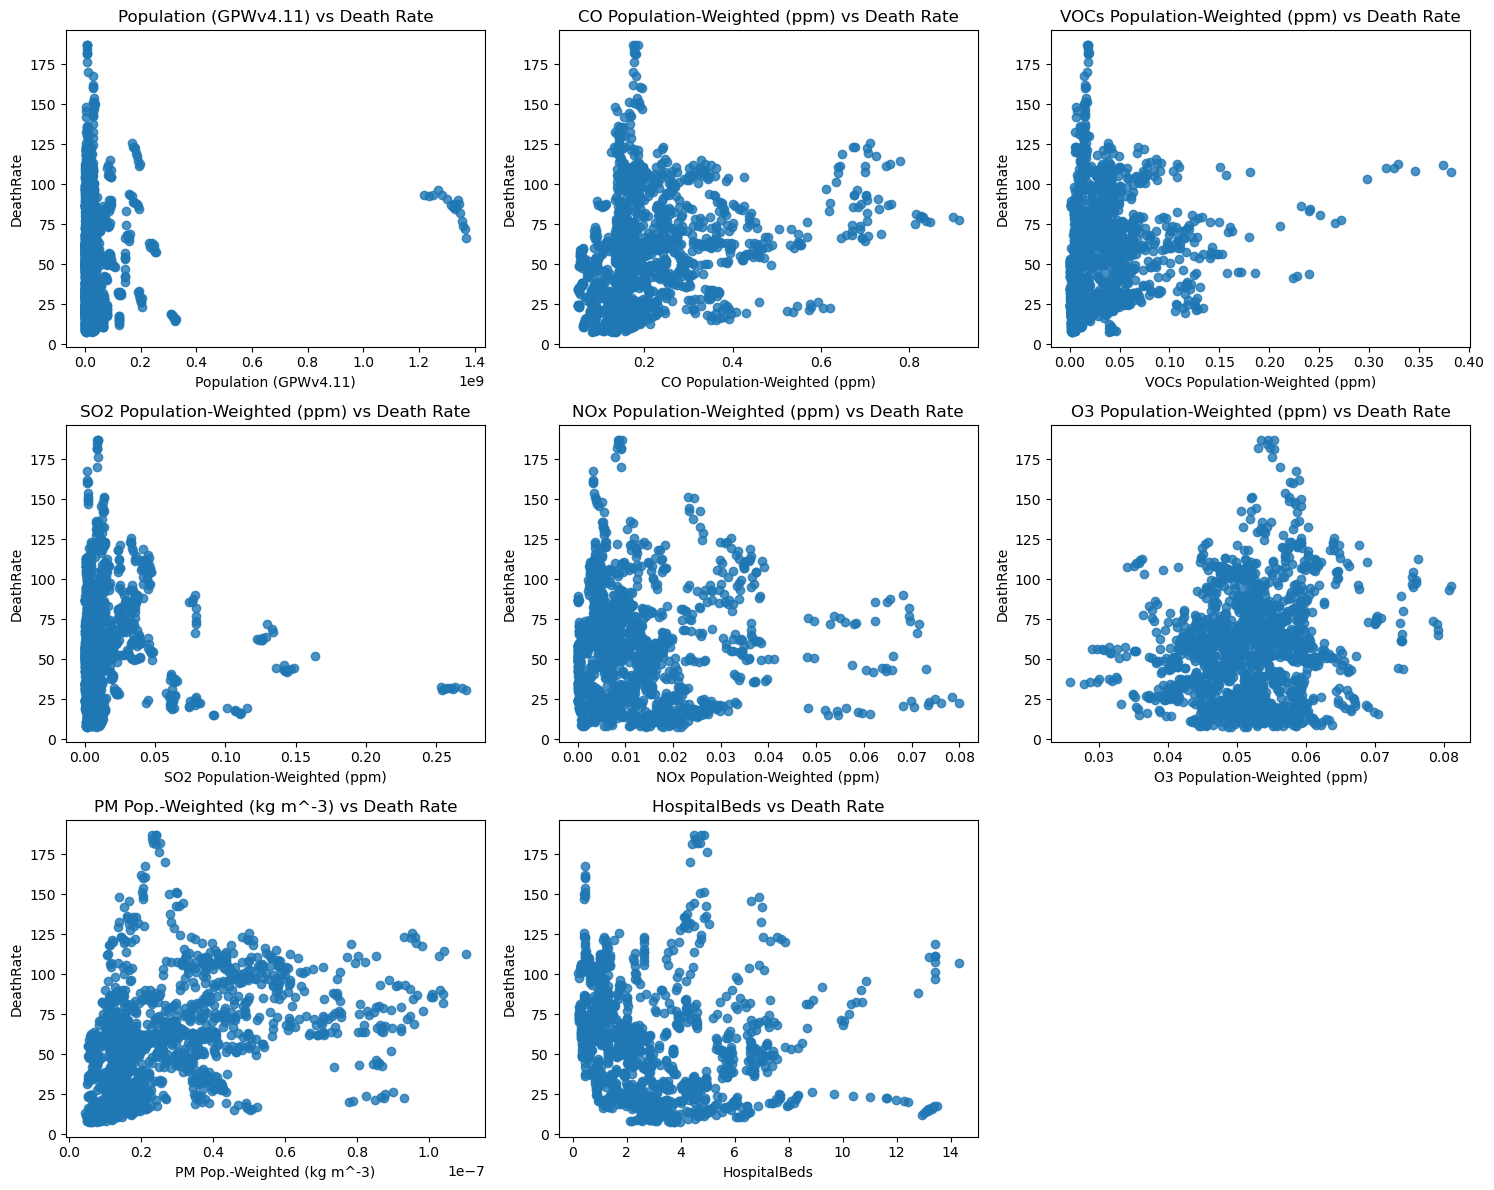

In [19]:
features = final_df.drop(columns=['ISO','Year','DeathRate']).columns

import math

n = len(features)
cols = 3                          # adjust to taste
rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows, cols,
                         figsize=(cols*5, rows*4),
                         squeeze=False)

for idx, feature in enumerate(features):
    r = idx // cols
    c = idx % cols
    sns.regplot(data=final_df, x=feature, y='DeathRate', ax=axes[r][c],fit_reg=False)
    axes[r][c].set_title(f"{feature} vs Death Rate")

# if the grid has unused axes, remove them
for j in range(idx+1, rows*cols):
    fig.delaxes(axes[j//cols][j%cols])

plt.tight_layout()
plt.show()

## Looking for the Outliers

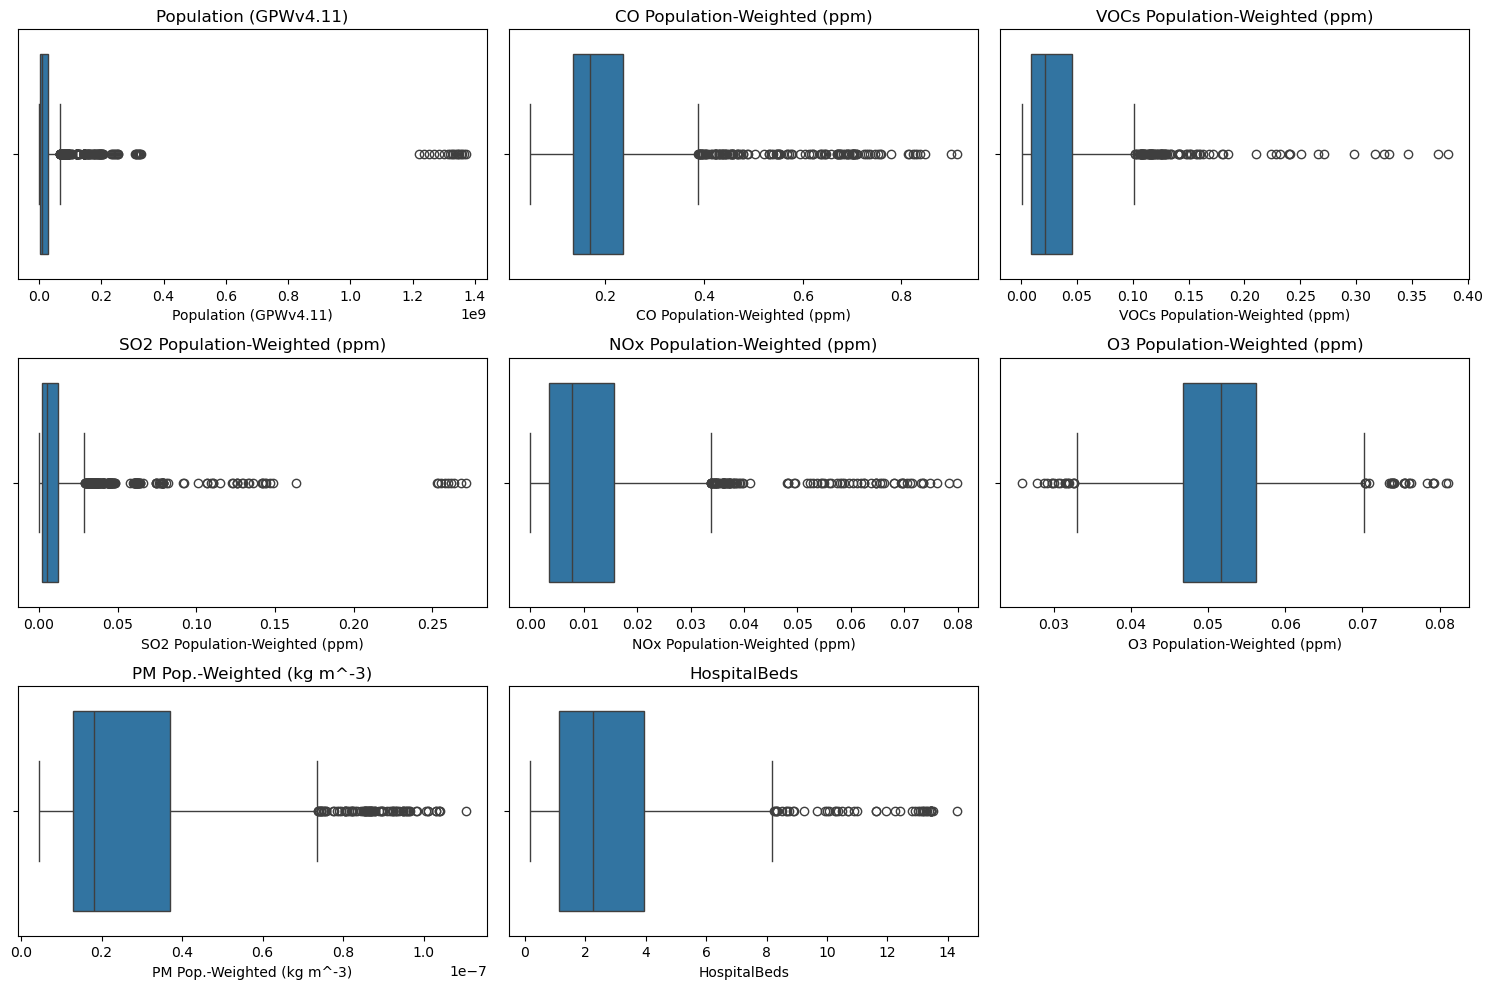

In [20]:
#getting outliers in the dataset using boxplot
cols = [col for col in final_df.columns if col not in ['ISO','Year','DeathRate']]

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)  # adjust grid depending on number of features
    sns.boxplot(x=final_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Numerical Skewness analysis

In [21]:
final_df.drop(columns=['ISO', 'Year', 'DeathRate']).skew().sort_values(ascending=False)

Population (GPWv4.11)             8.179615
SO2 Population-Weighted (ppm)     5.488493
VOCs Population-Weighted (ppm)    3.358911
NOx Population-Weighted (ppm)     2.272959
CO Population-Weighted (ppm)      2.231067
HospitalBeds                      1.718375
O3 Population-Weighted (ppm)      0.236396
PM Pop.-Weighted (kg m^-3)        0.000000
dtype: float64

## Log transformation

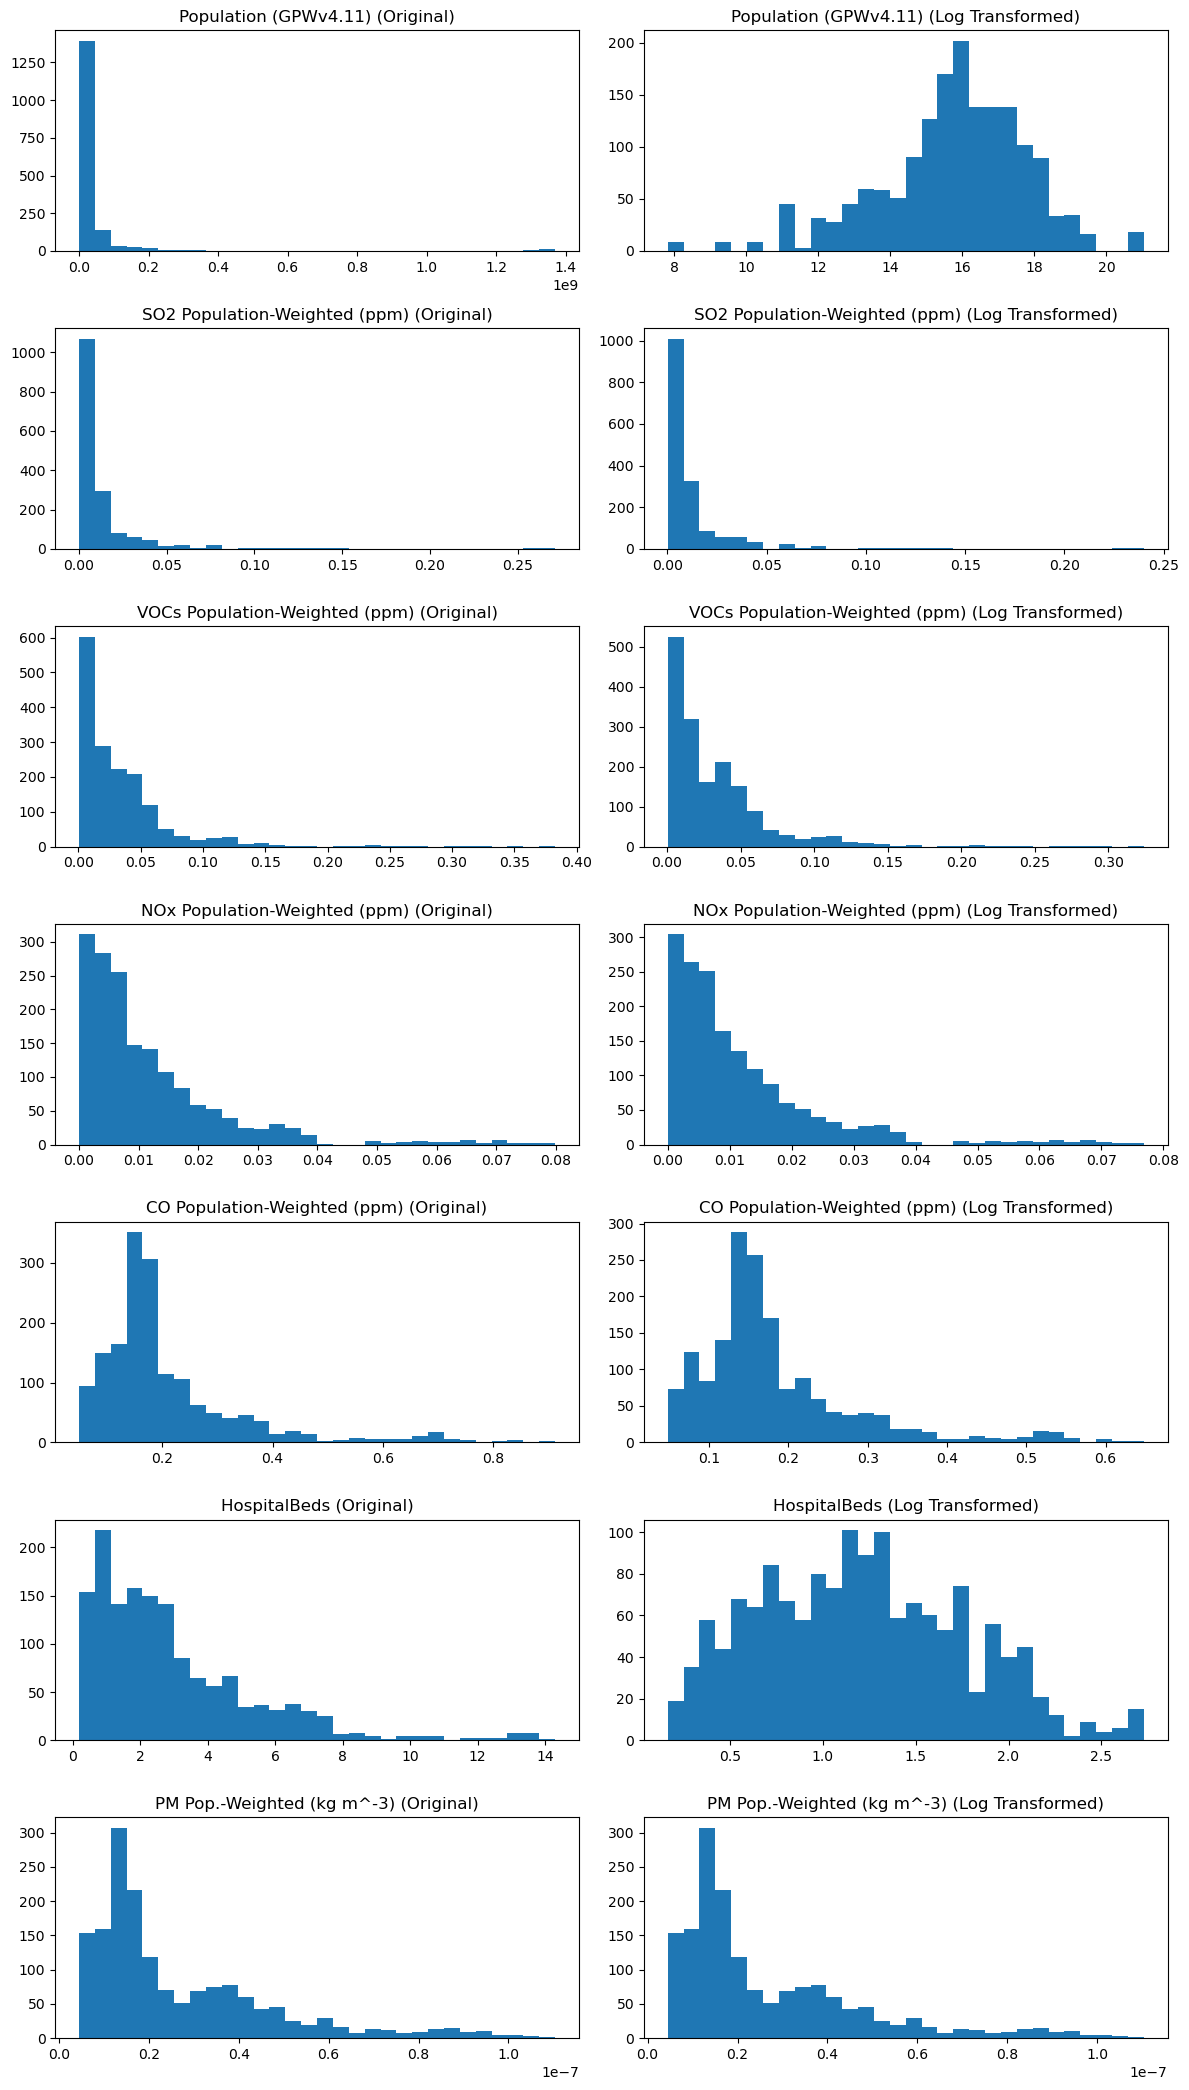

In [22]:
skewed_features = [
    'Population (GPWv4.11)',
    'SO2 Population-Weighted (ppm)',
    'VOCs Population-Weighted (ppm)',
    'NOx Population-Weighted (ppm)',
    'CO Population-Weighted (ppm)',
    'HospitalBeds',
    'PM Pop.-Weighted (kg m^-3)'
]
 
# Make a copy of dataset
transformed_df = final_df.copy()
 
# Apply log transformation
for col in skewed_features:
    transformed_df[col] = np.log1p(transformed_df[col])
 
# Plot before vs after histograms
rows = len(skewed_features)
plt.figure(figsize=(12, rows * 3))
 
for i, col in enumerate(skewed_features):
 
    # Original
    plt.subplot(rows, 2, 2*i + 1)
    plt.hist(final_df[col], bins=30)
    plt.title(f"{col} (Original)")
 
    # Transformed
    plt.subplot(rows, 2, 2*i + 2)
    plt.hist(transformed_df[col], bins=30)
    plt.title(f"{col} (Log Transformed)")
 
plt.tight_layout()
plt.show()
 


## Checking the skewness again with before transformation and after transformation

In [23]:
print("Before transformation")
print(final_df[skewed_features].skew().sort_values(ascending=False))

print("\nAfter transformation")
print(transformed_df[skewed_features].skew().sort_values(ascending=False))

# 

Before transformation
Population (GPWv4.11)             8.179615
SO2 Population-Weighted (ppm)     5.488493
VOCs Population-Weighted (ppm)    3.358911
NOx Population-Weighted (ppm)     2.272959
CO Population-Weighted (ppm)      2.231067
HospitalBeds                      1.718375
PM Pop.-Weighted (kg m^-3)        0.000000
dtype: float64

After transformation
SO2 Population-Weighted (ppm)     5.091803
VOCs Population-Weighted (ppm)    2.938689
NOx Population-Weighted (ppm)     2.210087
CO Population-Weighted (ppm)      1.822665
HospitalBeds                      0.294302
PM Pop.-Weighted (kg m^-3)        0.000000
Population (GPWv4.11)            -0.656681
dtype: float64


## Country wise Death rate analysis

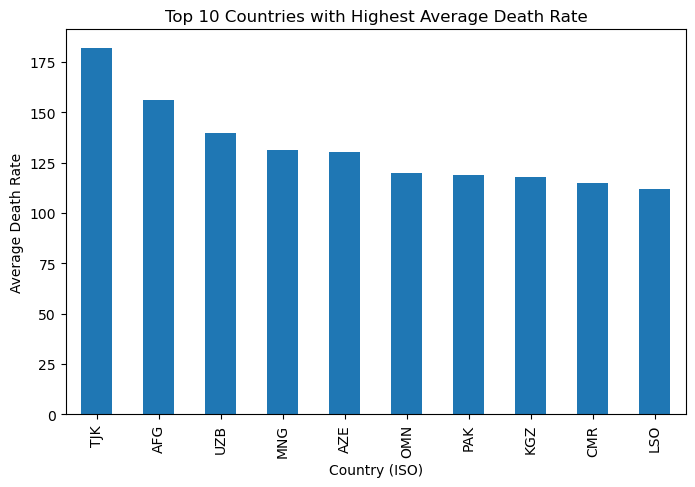

In [24]:
country_death = final_df.groupby('ISO')['DeathRate'].mean().sort_values(ascending=False)

country_death.head(10)

country_death.head(10).plot(kind='bar', figsize=(8,5))

plt.title("Top 10 Countries with Highest Average Death Rate")
plt.xlabel("Country (ISO)")
plt.ylabel("Average Death Rate")

plt.show()

In [25]:
country_death = final_df.groupby('ISO')['DeathRate'].mean().sort_values(ascending=False)

# Convert to dataframe
top10 = country_death.head(10).reset_index()
top10.columns = ['ISO', 'AverageDeathRate']

# Add region from ISO automatically
def iso_to_region(iso_code):
    try:
        country_alpha2 = pc.country_alpha3_to_country_alpha2(iso_code)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return 'Unknown'

top10['Region'] = top10['ISO'].apply(iso_to_region)

print(top10)

   ISO  AverageDeathRate  Region
0  TJK        181.933333    Asia
1  AFG        155.788889    Asia
2  UZB        139.577778    Asia
3  MNG        131.000000    Asia
4  AZE        130.455556    Asia
5  OMN        119.733333    Asia
6  PAK        118.988889    Asia
7  KGZ        117.715556    Asia
8  CMR        114.711111  Africa
9  LSO        111.988889  Africa


## Number of countries per each region

In [26]:
final_df['Region'] = final_df['ISO'].apply(iso_to_region)
region_country_counts = final_df.groupby('Region')['ISO'].nunique()
print(region_country_counts)
final_df = final_df.drop(columns=['Region'])

Region
Africa           54
Asia             46
Europe           39
North America    21
Oceania          10
South America    12
Unknown           1
Name: ISO, dtype: int64


## Time trend analysis

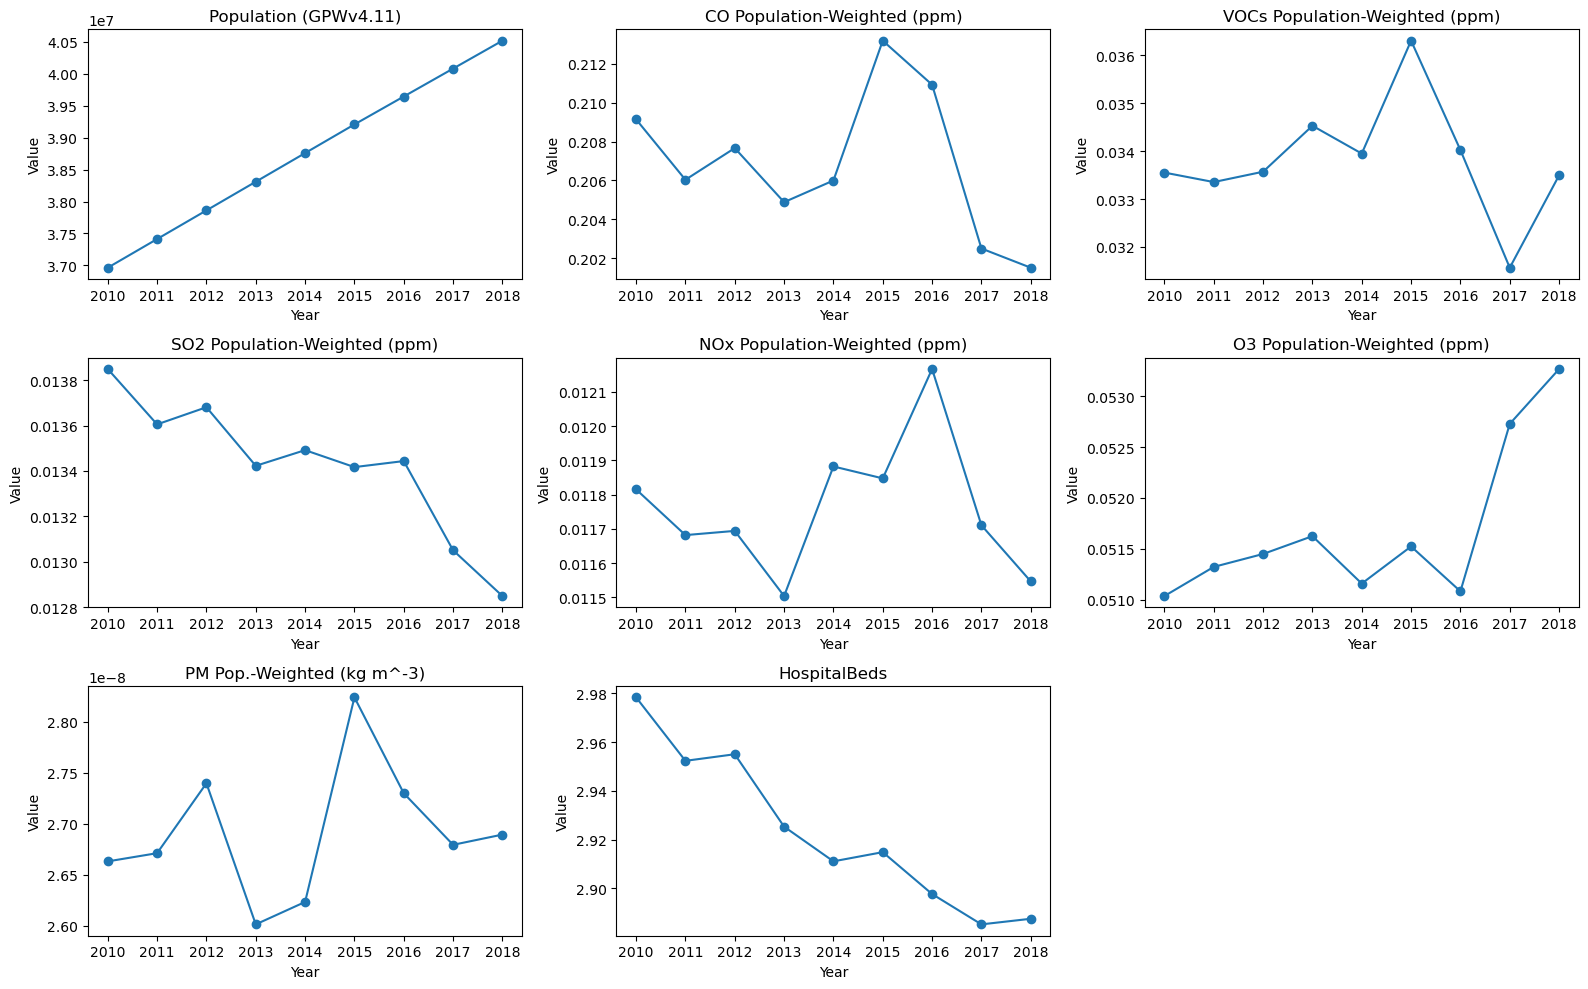

In [27]:
# group by year and take mean
yearly_trend = final_df.groupby('Year').mean(numeric_only=True)



plt.figure(figsize=(16,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.plot(yearly_trend.index, yearly_trend[col], marker='o')
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

## Since there are missing values for hospital beds, filling those with region wise median


In [28]:

# Using the log transformed dataframe to analyze missing values by region

def iso_to_region(iso_code):
    try:
        country_alpha2 = pc.country_alpha3_to_country_alpha2(iso_code.upper())
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        return pc.convert_continent_code_to_continent_name(continent_code)
    except:
        return 'Unknown'

transformed_df['Region'] = transformed_df['ISO'].apply(iso_to_region)

# Count missing values per region
missing_by_region = transformed_df[transformed_df['HospitalBeds'].isna()]['Region'].value_counts()

print("Missing HospitalBeds by Region:")
print(missing_by_region)

Missing HospitalBeds by Region:
Region
Africa     117
Oceania     45
Name: count, dtype: int64


**Missing hospital bed values are imputed using the median of countries within the same region and year, ensuring that both geographical and time-based patterns are preserved.**

In [29]:
# ─────────────────────────────────────────────────────────────
# STEP: REGION + YEAR BASED IMPUTATION (TIME-AWARE)
# Missing HospitalBeds values are filled using the median
# of countries within the same region and year
# ─────────────────────────────────────────────────────────────

# Step 0: Create a copy of original dataset
imputed_df = transformed_df.copy()

# Step 1: Calculate Region-Year median
region_year_median = imputed_df.groupby(['Region', 'Year'])['HospitalBeds'].transform('median')

# Step 2: Fill missing values in the COPY
imputed_df['HospitalBeds'] = imputed_df['HospitalBeds'].fillna(region_year_median)

# Step 3: Final check
print("\n✅ Imputation complete")
print(f"   Missing HospitalBeds after imputation: {imputed_df['HospitalBeds'].isna().sum()}")




✅ Imputation complete
   Missing HospitalBeds after imputation: 0


## Saving final cleaned datasets

In [30]:

# Rename iso column to Country_ISO in all datasets
final_df = final_df.rename(columns={'ISO': 'Country_ISO'})
transformed_df = transformed_df.rename(columns={'ISO': 'Country_ISO'})
imputed_df = imputed_df.rename(columns={'ISO': 'Country_ISO'})

# Remove Region column safely from both datasets
transformed_df = transformed_df.drop(columns=['Region'], errors='ignore')
imputed_df = imputed_df.drop(columns=['Region'], errors='ignore')

# Save the final raw dataset
final_df.to_csv(
    "final_datasets/final_raw_dataset.csv",
    index=False
)

# Save log transformed dataset (with null values) as single sheet
transformed_df.to_csv(
    "final_datasets/log_transformed_dataset(with-null-values).csv", 
    index=False
)

# Save imputed dataset and log transformed dataset (without null) values
imputed_df.to_csv(
    "final_datasets/log_transformed_dataset(without-null-values).csv", 
    index=False
)